In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r"C:\Users\Aaron\OneDrive\Desktop\Capstone\Data\Features"

precipitation = pd.read_csv(path + "\Weather\Precipitation1985_2025.csv")
sunshineDuration = pd.read_csv(path + "\Weather\SunshineDuration1985_2025.csv")
airTemperature = pd.read_csv(path + "\Weather\AirTemperature1985_2025.csv")

In [3]:
spring_wheat = pd.read_csv(path + "\CropYield\SpringWheat1985_2025.csv")[['Year','Tonnes']]

spring_wheat.head()

,Year,Tonnes
0,1985,5.8
1,1986,5.4
2,1987,6.2
3,1988,7.0
4,1989,6.2


In [4]:
import numpy as np

season_map = {
    'September': 'Autumn', 'October': 'Autumn', 'November': 'Autumn',
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
}

roll_forward = ['September', 'October', 'November', 'December']


def season_weather(monthly_average, colname):
    df = monthly_average.copy()
    df['Season'] = df['Month'].map(season_map)
 
    rollOn_month = df['Month'].isin(roll_forward)
    df['HarvestYear'] = np.where(rollOn_month, df['Year'] + 1, df['Year'])
 
    season_avg = df.groupby(['HarvestYear', 'Season'])['Measurement'].mean().reset_index()
 
    pivot = season_avg.pivot(index='HarvestYear', columns='Season', values='Measurement')
    pivot.columns = [f'{colname}_{s}' for s in pivot.columns]
 
    return pivot.reset_index().rename(columns={'HarvestYear': 'Year'})

In [5]:
def build_features(station='mean'):
    return (season_weather(precipitation, 'Precip')
            .merge(season_weather(sunshineDuration, 'Sun'), on='Year')
            .merge(season_weather(airTemperature, 'TempMean'), on='Year'))

In [6]:
features = build_features('mean')

In [7]:
def detrend_yield(yield_data):
    yield_copy = yield_data.copy()

    slope, intercept = np.polyfit(yield_copy['Year'], yield_copy['Tonnes'], deg=1)
    yield_copy['Trend'] = slope * yield_copy['Year'] + intercept
    yield_copy['Yield_Detrended'] = yield_copy['Tonnes'] - yield_copy['Trend']

    return yield_copy

In [8]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

In [9]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

def best_hyperparameters_xgboost(X, y):
    hyperparameter_grid = {
        'max_depth': [1, 2, 3, 4, 5],
        'n_estimators': [10, 20, 30, 40],
        'reg_alpha': [0.5, 1.0, 2.0],
        'reg_lambda': [0.5, 1.0, 2.0],
    }

    best_result = {'r2': -np.inf}

    for max_depth in hyperparameter_grid['max_depth']:
        for n_estimators in hyperparameter_grid['n_estimators']:
            for reg_alpha in hyperparameter_grid['reg_alpha']:
                for reg_lambda in hyperparameter_grid['reg_lambda']:

                    params = {
                        'max_depth': max_depth,
                        'n_estimators': n_estimators,
                        'reg_alpha': reg_alpha,
                        'reg_lambda': reg_lambda,
                    }

                    y_true = []
                    y_pred = []
                    for train_index, test_index in loo.split(X):
                        model = xgb.XGBRegressor(random_state=42, **params)
                        model.fit(X.iloc[train_index], y.iloc[train_index])
                        y_pred.append(model.predict(X.iloc[test_index])[0])
                        y_true.append(y.iloc[test_index].values[0])

                    r2 = r2_score(y_true, y_pred)

                    if r2 > best_result['r2']:
                        best_result = {'params': params, 'r2': r2}

    print(f"Best XGBoost hyperparameters: {best_result['params']}")
    print(f"R2: {best_result['r2']:.3f}")
    return best_result['params']


In [10]:
def best_hyperparameters_random_forest(X, y):
    hyperparameter_grid = {
        'n_estimators': [50, 100],
        'max_depth': [2, 3, 4],
        'min_samples_leaf': [1, 2, 3],
    }

    best_result = {'r2': -np.inf}

    for n_estimators in hyperparameter_grid['n_estimators']:
        for max_depth in hyperparameter_grid['max_depth']:
            for min_samples_leaf in hyperparameter_grid['min_samples_leaf']:

                params = {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_leaf': min_samples_leaf,
                }

                y_true = []
                y_pred = []
                for train_index, test_index in loo.split(X):
                    model = RandomForestRegressor(random_state=42, **params)
                    model.fit(X.iloc[train_index], y.iloc[train_index])
                    y_pred.append(model.predict(X.iloc[test_index])[0])
                    y_true.append(y.iloc[test_index].values[0])

                r2 = r2_score(y_true, y_pred)

                if r2 > best_result['r2']:
                    best_result = {'params': params, 'r2': r2}

    print(f"Best Random Forest hyperparameters: {best_result['params']}")
    print(f"R2: {best_result['r2']:.3f}")
    return best_result['params']

In [11]:
def run_xgboost(X, y, params):
    y_true = []
    y_pred = []
 
    for train_index, test_index in loo.split(X):
        model = xgb.XGBRegressor(random_state=42, **params)
        model.fit(X.iloc[train_index], y.iloc[train_index])
 
        y_pred.append(model.predict(X.iloc[test_index])[0])
        y_true.append(y.iloc[test_index].values[0])
 
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
 
    return rmse, mae, r2

In [12]:
def run_random_forest(X, y, params):
    y_true = []
    y_pred = []
 
    for train_index, test_index in loo.split(X):
        model = RandomForestRegressor(random_state=42, **params)
        model.fit(X.iloc[train_index], y.iloc[train_index])
 
        y_pred.append(model.predict(X.iloc[test_index])[0])
        y_true.append(y.iloc[test_index].values[0])
 
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
 
    return rmse, mae, r2

In [13]:
crops_info = [
    (path + r"\CropYield\SpringWheat1985_2025.csv", 'SpringWheat'),
    (path + r"\CropYield\WinterWheat1985_2025.csv", 'WinterWheat'),
    (path + r"\CropYield\SpringBarley1985_2025.csv", 'SpringBarley'),
    (path + r"\CropYield\WinterBarley1985_2025.csv", 'WinterBarley'),
    (path + r"\CropYield\SpringOats1985_2025.csv", 'SpringOats'),
    (path + r"\CropYield\WinterOats1985_2025.csv", 'WinterOats'),
    (path + r"\CropYield\Potatoes1985_2025.csv", 'Potatoes'),
    (path + r"\CropYield\OilseedRape1985_2025.csv", 'OilseedRape'),
    (path + r"\CropYield\BeansAndPeas1985_2025.csv", 'BeansAndPeas'),
]

In [14]:
reference_yield = detrend_yield(pd.read_csv(crops_info[0][0])[['Year', 'Tonnes']])


reference_data = features.merge(reference_yield, on='Year').dropna().sort_values('Year').reset_index(drop=True)
X_reference = reference_data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
y_reference = reference_data['Yield_Detrended']

params_xgboost = best_hyperparameters_xgboost(X_reference, y_reference)
params_random_forest = best_hyperparameters_random_forest(X_reference, y_reference)

Best XGBoost hyperparameters: {'max_depth': 1, 'n_estimators': 30, 'reg_alpha': 0.5, 'reg_lambda': 0.5}
R2: 0.272
Best Random Forest hyperparameters: {'n_estimators': 100, 'max_depth': 3, 'min_samples_leaf': 2}
R2: 0.232


In [15]:
def permutation_test_xgboost(X, y, params, n_shuffles=2000, seed=42):
    rng = np.random.default_rng(seed)
 
    _, _, observed_r2 = run_xgboost(X, y, params)
 
    permuted_r2_scores = []
    for i in range(n_shuffles):
        shuffled_y = pd.Series(rng.permutation(y.values), index=y.index)
        _, _, permuted_r2 = run_xgboost(X, shuffled_y, params)
        permuted_r2_scores.append(permuted_r2)
 
    permuted_r2_scores = np.array(permuted_r2_scores)
    number_at_least_as_good = np.sum(permuted_r2_scores >= observed_r2)
    p_value = (number_at_least_as_good + 1) / (n_shuffles + 1)
 
    return observed_r2, p_value

In [ ]:
def permutation_test_rforest(X, y, params, n_shuffles=2000, seed=42):
    rng = np.random.default_rng(seed)
 
    _, _, observed_r2 = run_random_forest(X, y, params)
 
    permuted_r2_scores = []
    
    for i in range(n_shuffles):
        shuffled_y = pd.Series(rng.permutation(y.values), index=y.index)
        _, _, permuted_r2 = run_random_forest(X, shuffled_y, params)
        permuted_r2_scores.append(permuted_r2)
 
    permuted_r2_scores = np.array(permuted_r2_scores)
    number_at_least_as_good = np.sum(permuted_r2_scores >= observed_r2)
    p_value = (number_at_least_as_good + 1) / (n_shuffles + 1)
 
    return observed_r2, p_value

In [17]:
all_results = []
 
for csv_path, crop_name in crops_info:
 
    # Build this crop's detrended yield and merge with the shared weather features
    yield_df = detrend_yield(pd.read_csv(csv_path)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    print(f"\n=== {crop_name} (n={len(data)}, features={X.shape[1]}) ===")
 
    # --- XGBoost ---
    rmse_xgb, mae_xgb, r2_xgb = run_xgboost(X, y, params_xgboost)
    observed_r2_xgb, p_value_xgb = permutation_test_xgboost(X, y, params_xgboost, n_shuffles=500)
 
    print(f"XGBoost:       RMSE={rmse_xgb:.3f}  MAE={mae_xgb:.3f}  R2={r2_xgb:.3f}  p={p_value_xgb:.4f}")
 
    all_results.append({
        'crop': crop_name, 'model': 'xgboost',
        'rmse': rmse_xgb, 'mae': mae_xgb, 'r2': r2_xgb, 'p_value': p_value_xgb,
    })
 
    # --- Random Forest ---
    rmse_rf, mae_rf, r2_rf = run_random_forest(X, y, params_random_forest)
 
    print(f"Random Forest: RMSE={rmse_rf:.3f}  MAE={mae_rf:.3f}  R2={r2_rf:.3f}")
 
    all_results.append({
        'crop': crop_name, 'model': 'random_forest',
        'rmse': rmse_rf, 'mae': mae_rf, 'r2': r2_rf, 'p_value': None,
    })


=== SpringWheat (n=40, features=12) ===
XGBoost:       RMSE=0.570  MAE=0.461  R2=0.272  p=0.0040
Random Forest: RMSE=0.585  MAE=0.467  R2=0.232

=== WinterWheat (n=40, features=12) ===
XGBoost:       RMSE=0.924  MAE=0.715  R2=-0.100  p=0.2156
Random Forest: RMSE=0.897  MAE=0.738  R2=-0.039

=== SpringBarley (n=40, features=12) ===
XGBoost:       RMSE=0.446  MAE=0.361  R2=0.414  p=0.0020
Random Forest: RMSE=0.512  MAE=0.416  R2=0.228

=== WinterBarley (n=40, features=12) ===
XGBoost:       RMSE=0.667  MAE=0.514  R2=0.008  p=0.0938
Random Forest: RMSE=0.655  MAE=0.518  R2=0.041

=== SpringOats (n=40, features=12) ===
XGBoost:       RMSE=0.402  MAE=0.301  R2=0.337  p=0.0020
Random Forest: RMSE=0.439  MAE=0.323  R2=0.207

=== WinterOats (n=40, features=12) ===
XGBoost:       RMSE=0.472  MAE=0.362  R2=-0.057  p=0.1916
Random Forest: RMSE=0.474  MAE=0.376  R2=-0.064

=== Potatoes (n=40, features=12) ===
XGBoost:       RMSE=2.909  MAE=2.276  R2=0.401  p=0.0020
Random Forest: RMSE=3.457  MAE=

In [18]:
results_table = pd.DataFrame(all_results)
 
print("\n\n=== FINAL R2 TABLE ===")
print(results_table.pivot(index='crop', columns='model', values='r2').round(3))
 
print("\n=== FINAL RMSE TABLE ===")
print(results_table.pivot(index='crop', columns='model', values='rmse').round(3))
 
print("\n=== FINAL MAE TABLE ===")
print(results_table.pivot(index='crop', columns='model', values='mae').round(3))
 
print("\n=== XGBOOST PERMUTATION TEST P-VALUES ===")
xgboost_only = results_table[results_table['model'] == 'xgboost']
print(xgboost_only[['crop', 'r2', 'p_value']].round(4))



=== FINAL R2 TABLE ===
model         random_forest  xgboost
crop                                
BeansAndPeas         -0.289   -0.139
OilseedRape          -0.246   -0.216
Potatoes              0.155    0.401
SpringBarley          0.228    0.414
SpringOats            0.207    0.337
SpringWheat           0.232    0.272
WinterBarley          0.041    0.008
WinterOats           -0.064   -0.057
WinterWheat          -0.039   -0.100

=== FINAL RMSE TABLE ===
model         random_forest  xgboost
crop                                
BeansAndPeas          1.471    1.383
OilseedRape           0.873    0.862
Potatoes              3.457    2.909
SpringBarley          0.512    0.446
SpringOats            0.439    0.402
SpringWheat           0.585    0.570
WinterBarley          0.655    0.667
WinterOats            0.474    0.472
WinterWheat           0.897    0.924

=== FINAL MAE TABLE ===
model         random_forest  xgboost
crop                                
BeansAndPeas          1.142    1.049

In [21]:
winter_crops_info = [
    (path + r"\CropYield\WinterWheat1985_2025.csv", 'WinterWheat'),
    (path + r"\CropYield\WinterBarley1985_2025.csv", 'WinterBarley'),
    (path + r"\CropYield\WinterOats1985_2025.csv", 'WinterOats'),
]
 
for csv_path, crop_name in winter_crops_info:
 
    yield_df = detrend_yield(pd.read_csv(csv_path)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    print(f"\n=== {crop_name} ===")
 
    params_winter = best_hyperparameters_xgboost(X, y)
 
    rmse, mae, r2 = run_xgboost(X, y, params_winter)
    observed_r2, p_value = permutation_test_xgboost(X, y, params_winter, n_shuffles=2000)
 
    print(f"RMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}  p={p_value:.4f}  significant={p_value < 0.05}")


=== WinterWheat ===
Best XGBoost hyperparameters: {'max_depth': 2, 'n_estimators': 20, 'reg_alpha': 0.5, 'reg_lambda': 1.0}
R2: 0.172
RMSE=0.801  MAE=0.651  R2=0.172  p=0.0155  significant=True

=== WinterBarley ===
Best XGBoost hyperparameters: {'max_depth': 5, 'n_estimators': 20, 'reg_alpha': 2.0, 'reg_lambda': 1.0}
R2: 0.090
RMSE=0.639  MAE=0.472  R2=0.090  p=0.0370  significant=True

=== WinterOats ===
Best XGBoost hyperparameters: {'max_depth': 1, 'n_estimators': 10, 'reg_alpha': 2.0, 'reg_lambda': 0.5}
R2: 0.032
RMSE=0.452  MAE=0.365  R2=0.032  p=0.0780  significant=False



SpringWheat


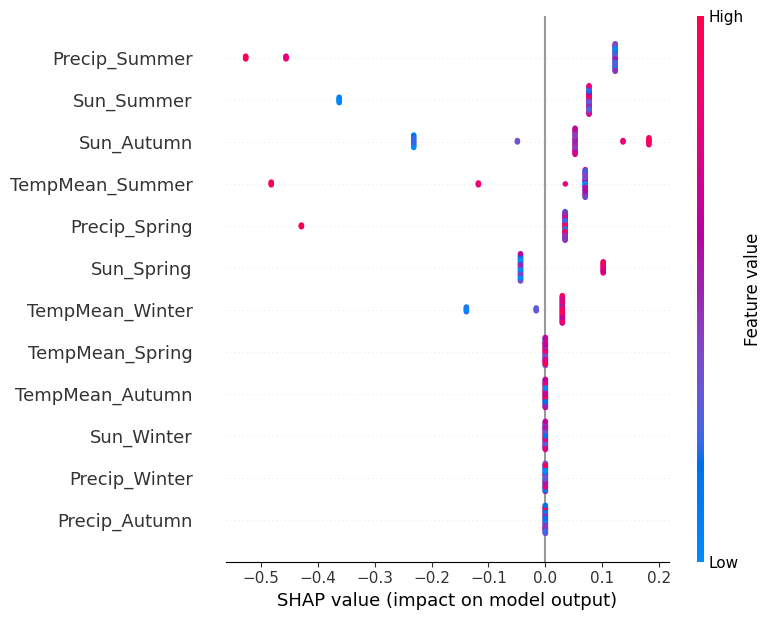


SpringBarley


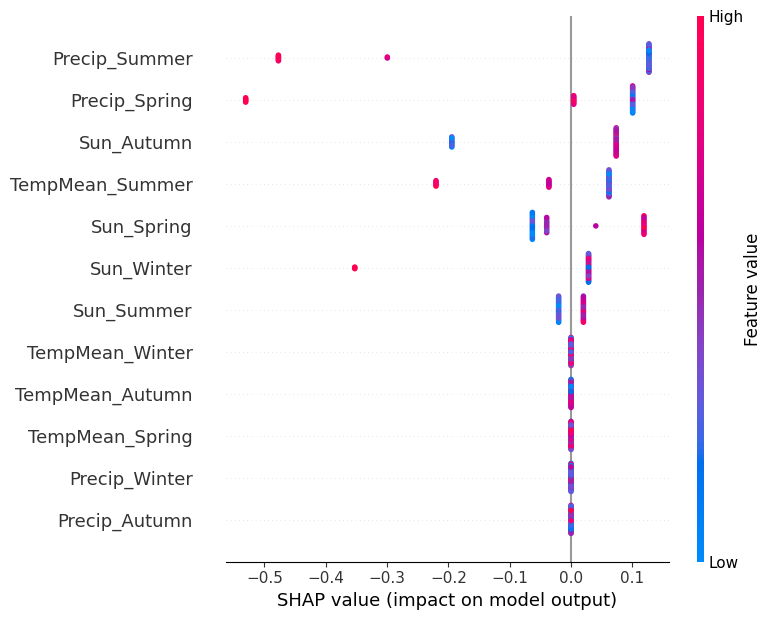


SpringOats


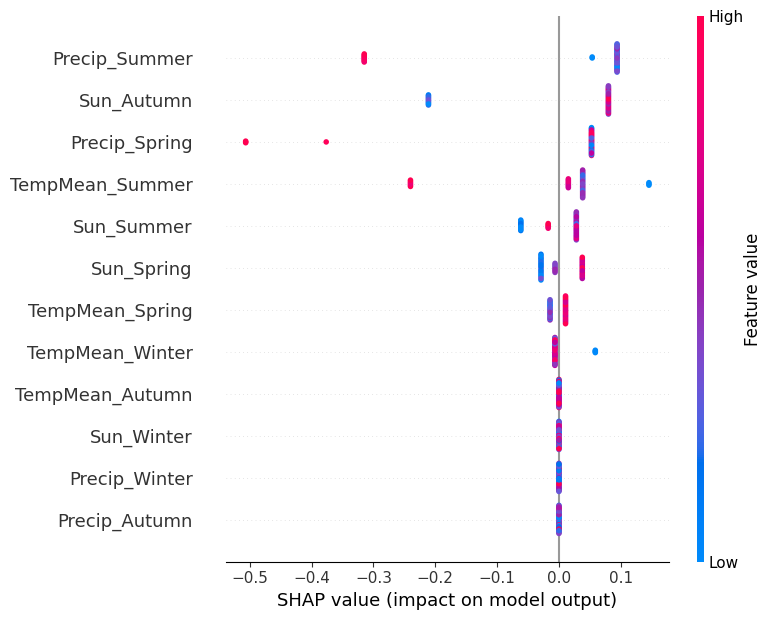


Potatoes


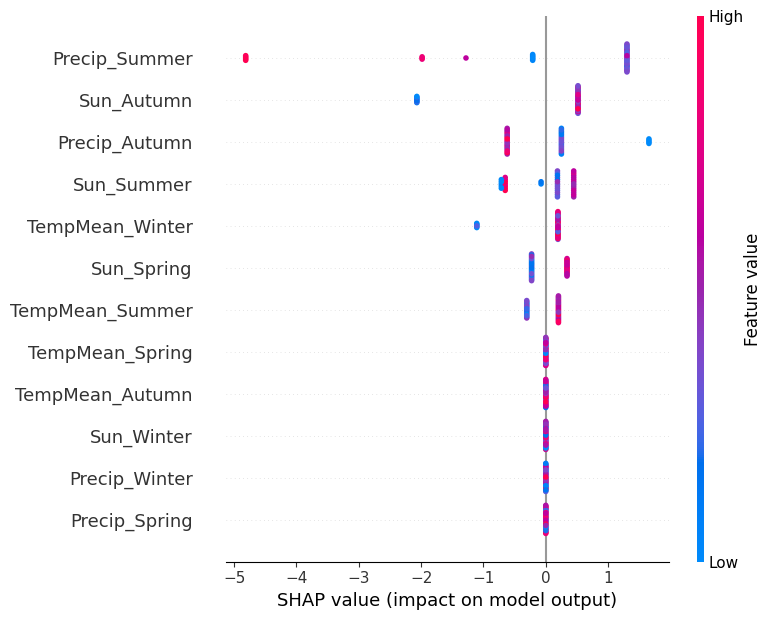

In [ ]:
import shap
 
shap_crops = [
    (path + "\CropYield\SpringWheat1985_2025.csv", 'SpringWheat'),
    (path + "\CropYield\SpringBarley1985_2025.csv", 'SpringBarley'),
    (path + "\CropYield\SpringOats1985_2025.csv", 'SpringOats'),
    (path + "\CropYield\Potatoes1985_2025.csv", 'Potatoes'),
]
 
for csv_path, crop_name in shap_crops:
 
    yield_df = detrend_yield(pd.read_csv(csv_path)[['Year', 'Tonnes']])
    data = features.merge(yield_df, on='Year').dropna().sort_values('Year').reset_index(drop=True)
 
    X = data.drop(columns=['Year', 'Tonnes', 'Trend', 'Yield_Detrended'])
    y = data['Yield_Detrended']
 
    model = xgb.XGBRegressor(random_state=42, **params_xgboost)
    model.fit(X, y)
 
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
 
    print(f"\n{crop_name}")
    shap.summary_plot(shap_values, X)